This notebook tests the ResNet-18 architecture on the KDEF dataset only.

The ResNet-18 model utilizes pre-trained weights, and the KDEF dataset is train throughout the networks layers.

Model Parameters:
* optimizer = Adam [lr = 0.001, weight_decay=0.01]
* loss function = Cross Entropy Loss (weights = None)

Early stopping is applied to combat overfitting. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/user/HS401/ob00564/Documents/COM3001/All/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/All
cuda


In [3]:
train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers=8 )
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers=8)

Train set length: 3241
Test set length: 404
Validation set length: 408


In [4]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 396, '1': 406, '2': 382, '3': 416, '4': 382, '5': 425, '6': 834}
{'0': 49, '1': 51, '2': 47, '3': 52, '4': 48, '5': 53, '6': 104}
{'0': 50, '1': 51, '2': 48, '3': 52, '4': 48, '5': 54, '6': 105}


In [5]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.resnet18(weights = 'DEFAULT')
# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.fc.parameters():
    param.requires_grad = True

for param in myModel.layer4.parameters():
    param.requires_grad = True

myModel.fc = nn.Sequential(nn.Linear(myModel.fc.in_features,emotionTotal))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)
# print(device)


cuda


In [ ]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.001, momentum=0.9, weight_decay= 0.01)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)
lr_scheduler_a = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode='min', patience=6, factor=0.1)
train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, lr_scheduler_a, 100, criterion, name = 'All/Transfer Learning/All ResNet18.pth')
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')

100%|██████████| 203/203 [00:03<00:00, 66.05it/s]


Epoch 1/250, Training Loss: 1.6835, Validation Loss: 1.3264
Epoch 1/250, Training Acc: 38.98125342090859, Validation Accuracy: 57.932692307692314


100%|██████████| 203/203 [00:02<00:00, 70.24it/s]


Epoch 2/250, Training Loss: 1.1548, Validation Loss: 0.9711
Epoch 2/250, Training Acc: 63.38943623426382, Validation Accuracy: 70.1923076923077


100%|██████████| 203/203 [00:02<00:00, 70.49it/s]


...

Epoch 27/250, Training Loss: 0.0944, Validation Loss: 0.3174
Epoch 27/250, Training Acc: 97.69088669950739, Validation Accuracy: 88.70192307692307


100%|██████████| 203/203 [00:02<00:00, 67.98it/s]


Epoch 28/250, Training Loss: 0.0843, Validation Loss: 0.3136
Epoch 28/250, Training Acc: 98.21428571428571, Validation Accuracy: 88.70192307692307


100%|██████████| 203/203 [00:03<00:00, 67.26it/s]


Model saved successfully!
Test Loss: 0.3288, Test Accuracy: 89.46%


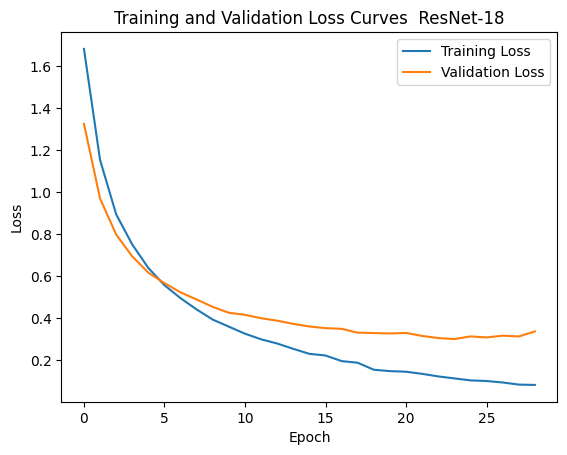

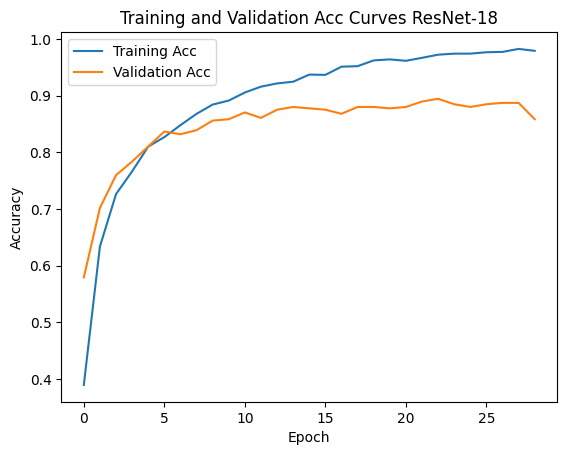

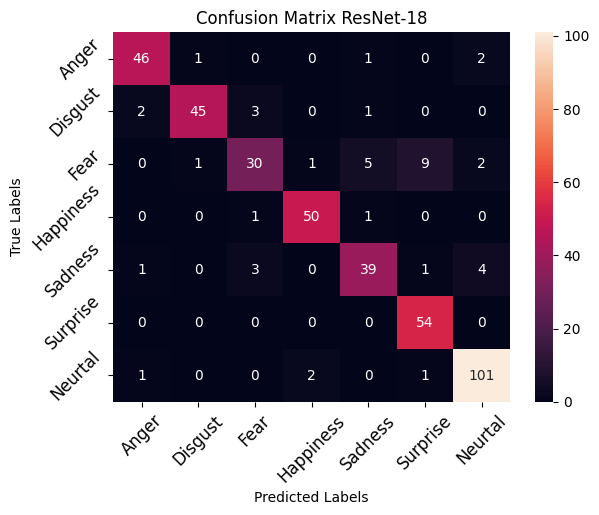

              precision    recall  f1-score   support

       Anger     0.9200    0.9200    0.9200        50
     Disgust     0.9574    0.8824    0.9184        51
        Fear     0.8108    0.6250    0.7059        48
   Happiness     0.9434    0.9615    0.9524        52
     Sadness     0.8298    0.8125    0.8211        48
    Surprise     0.8308    1.0000    0.9076        54
     Neurtal     0.9266    0.9619    0.9439       105

    accuracy                         0.8946       408
   macro avg     0.8884    0.8805    0.8813       408
weighted avg     0.8941    0.8946    0.8916       408



In [7]:
lossPlot(train_losses, val_losses, ' ResNet-18')
accuracyPlot(train_accuracy, val_accuracy, ' ResNet-18')
confusionMatrixPlot(y_true, y_pred, ' ResNet-18')